# MVP v0.1: Stitch-OPE on Robomimic — Pipeline Smoke Test

**Date:** 2026-03-10

**Goal:** Validate the full SOPE pipeline end-to-end on robomimic Lift:
1. **Off-policy data** — 200 human demonstrations (not target policy rollouts)
2. **Existing pre-trained diffusion policy** as target (no training needed)
3. **Unguided stitching** — validates pipeline before adding guidance complexity
4. **SOPE's code directly** — TemporalUnet + GaussianDiffusion from reference implementation

**Pipeline:**
- Step 0: Load demo data → SOPE format
- Step 1: Oracle rollouts (existing diffusion policy → ground truth V^π)
- Step 2: Train chunk diffusion on demo data
- Step 3: Chunk reconstruction sanity check
- Step 4: Unguided stitching → generate full trajectories
- Step 5: Score + evaluate (compare OPE estimate to oracle)

**Note:** Without guidance, OPE estimates the behavior policy (human demos) value, not the target policy value. This is expected — guidance will be added in v0.2.

In [1]:
import sys, os
import numpy as np
import torch
import h5py
import json
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from copy import deepcopy
from tqdm import tqdm

# Project root
PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

# SOPE imports
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

# Robomimic imports
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
from robomimic.algo import RolloutPolicy

# Our imports
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_rollout_policy_from_checkpoint, build_env_from_checkpoint
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
RESULTS_DIR = PROJECT_ROOT / "results/2026-03-10"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## Configuration

All hyperparameters in one place. We drop quaternions (cube_quat indices 3-6, eef_quat indices 13-16)
and orientation action dims (indices 3-5) to get state_dim=11, action_dim=4, transition_dim=15.

In [2]:
# ── Obs keys (sorted, matching robomimic convention) ──
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]
# Full 19-dim latent layout:
#   0-9:  object (cube_pos[3], cube_quat[4], gripper_to_cube[3])
#   10-12: robot0_eef_pos (3)
#   13-16: robot0_eef_quat (4)
#   17-18: robot0_gripper_qpos (2)

# Indices to KEEP (drop cube_quat[3:7] → indices 3,4,5,6 and eef_quat → indices 13,14,15,16)
STATE_KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]  # 11 dims
# Resulting layout:
#   0-2: cube_pos (3)
#   3-5: gripper_to_cube (3)
#   6-8: eef_pos (3)
#   9-10: gripper_qpos (2)

# Action indices to KEEP (drop orientation deltas 3,4,5)
ACTION_KEEP_INDICES = [0, 1, 2, 6]  # 4 dims: position deltas (3) + gripper (1)

STATE_DIM = len(STATE_KEEP_INDICES)   # 11
ACTION_DIM = len(ACTION_KEEP_INDICES) # 4
TRANSITION_DIM = STATE_DIM + ACTION_DIM  # 15

# ── Diffusion config ──
CHUNK_SIZE = 4          # T: mini-trajectory length (SOPE uses 4 for Cheetah)
N_DIFFUSION_STEPS = 256 # D: number of denoising steps
DIM_MULTS = (1, 4, 8)  # SOPE Cheetah config for T=4 (only 2 downsample levels)
BASE_DIM = 32
ACTION_WEIGHT = 5.0
PREDICT_EPSILON = False  # x0-prediction: much better on limited data/training (see D2.1 results)

# ── Training config (10x reduced for smoke test) ──
TRAIN_EPOCHS = 10
TRAIN_STEPS_PER_EPOCH = 1000
BATCH_SIZE = 128
LR = 3e-4
GRADIENT_ACCUMULATE = 1
STRIDE = 1  # chunk extraction stride

# ── Oracle config ──
# Use pre-collected 50 oracle rollouts from disk
ORACLE_JSON = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/oracle_50.json"

# ── OPE config ──
NUM_SYNTHETIC_TRAJS = 50   # batch size for unguided generation
T_GEN = 60                 # generation horizon (Lift episodes are ~60 steps)
GAMMA = 1.0                # undiscounted

# ── Reward ──
CUBE_Z_INDEX = 2           # index in reduced state (cube_pos z)
LIFT_THRESHOLD = 0.84      # table_height(0.8) + 0.04

print(f"state_dim={STATE_DIM}, action_dim={ACTION_DIM}, transition_dim={TRANSITION_DIM}")
print(f"Chunk size T={CHUNK_SIZE}, diffusion steps D={N_DIFFUSION_STEPS}")
print(f"dim_mults={DIM_MULTS}, base_dim={BASE_DIM}, predict_epsilon={PREDICT_EPSILON}")
print(f"Training: {TRAIN_EPOCHS} epochs × {TRAIN_STEPS_PER_EPOCH} steps = {TRAIN_EPOCHS * TRAIN_STEPS_PER_EPOCH:,} total steps")

state_dim=11, action_dim=4, transition_dim=15
Chunk size T=4, diffusion steps D=256
dim_mults=(1, 4, 8), base_dim=32, predict_epsilon=False
Training: 10 epochs × 1000 steps = 10,000 total steps


## Step 0: Load Demo Data → SOPE Format

Load robomimic's 200 human demonstrations from HDF5, concatenate obs keys into flat state vectors,
drop quaternions, and convert to SOPE's `DataType = List[Dict]` format.

In [3]:
def load_robomimic_demos(hdf5_path, obs_keys, state_keep_idx, action_keep_idx):
    """Load robomimic demos from HDF5 and convert to SOPE DataType format.
    
    Returns:
        data: List[Dict] with keys 'states', 'actions', 'rewards', 'next-states'
        all_states: np.ndarray of all states concatenated (for normalization)
        all_actions: np.ndarray of all actions concatenated (for normalization)
    """
    data = []
    all_states_list = []
    all_actions_list = []
    
    with h5py.File(hdf5_path, "r") as f:
        demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        print(f"Found {len(demo_keys)} demos")
        
        for dk in tqdm(demo_keys, desc="Loading demos"):
            demo = f["data"][dk]
            
            # Concatenate obs keys into flat state vector (sorted order)
            obs_arrays = [demo["obs"][k][:] for k in obs_keys]
            full_state = np.concatenate(obs_arrays, axis=-1)  # (T, 19)
            
            # Drop quaternion dims
            state = full_state[:, state_keep_idx].astype(np.float32)  # (T, 11)
            
            # Load and filter actions
            full_actions = demo["actions"][:].astype(np.float32)  # (T, 7)
            actions = full_actions[:, action_keep_idx]  # (T, 4)
            
            # Rewards
            rewards = demo["rewards"][:].astype(np.float32)  # (T,)
            
            # SOPE format: states[:-1], actions, next-states = states[1:]
            episode = {
                "states": state[:-1],        # (T-1, 11)
                "actions": actions[:-1],     # (T-1, 4) — align with state transitions
                "rewards": rewards[:-1],     # (T-1,)
                "next-states": state[1:],    # (T-1, 11)
            }
            data.append(episode)
            all_states_list.append(state)
            all_actions_list.append(actions)
    
    all_states = np.concatenate(all_states_list, axis=0)
    all_actions = np.concatenate(all_actions_list, axis=0)
    
    total_transitions = sum(len(ep["states"]) for ep in data)
    print(f"Loaded {len(data)} episodes, {total_transitions} total transitions")
    print(f"State shape: {data[0]['states'].shape}, Action shape: {data[0]['actions'].shape}")
    
    return data, all_states, all_actions

offline_data, all_states, all_actions = load_robomimic_demos(
    DEMO_HDF5, OBS_KEYS, STATE_KEEP_INDICES, ACTION_KEEP_INDICES
)

Found 200 demos


Loading demos:   0%|          | 0/200 [00:00<?, ?it/s]

Loading demos:  42%|████▎     | 85/200 [00:00<00:00, 845.40it/s]

Loading demos:  86%|████████▌ | 171/200 [00:00<00:00, 852.39it/s]

Loading demos: 100%|██████████| 200/200 [00:00<00:00, 848.44it/s]

Loaded 200 episodes, 9466 total transitions
State shape: (58, 11), Action shape: (58, 4)


In [4]:
# ── Compute normalization stats (SOPE-style: per-dim mean/std over full dataset) ──
# all_states is already filtered to 11 dims, all_actions to 4 dims
mean_state = np.mean(all_states, axis=0)
std_state = np.std(all_states, axis=0)
mean_action = np.mean(all_actions, axis=0)
std_action = np.std(all_actions, axis=0)

# Concatenated normalization for [state, action] vectors
norm_mean = np.concatenate([mean_state, mean_action]).astype(np.float32)
norm_std = np.concatenate([std_state, std_action]).astype(np.float32)

# Avoid division by zero
norm_std = np.maximum(norm_std, 1e-6)

norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)

normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

print(f"Normalization mean: {norm_mean}")
print(f"Normalization std:  {norm_std}")

Normalization mean: [ 1.8535433e-03 -8.7741995e-04  8.2473952e-01  2.4360158e-02
  8.7352633e-04 -6.7988336e-02 -2.2506613e-02 -1.7509464e-03
  8.9272785e-01  3.3776820e-02 -3.4069151e-02  1.7247589e-01
  5.8145039e-03 -1.6882959e-01 -4.0761432e-01]
Normalization std:  [0.0170806  0.01717002 0.01214484 0.04017279 0.01094779 0.06804574
 0.04077796 0.01568661 0.06509778 0.00757915 0.00721593 0.25917605
 0.12982461 0.4939424  0.9131541 ]


## Step 1: Oracle Values (Ground Truth V^π)

Load pre-collected oracle rollouts from disk (50 rollouts of the diffusion policy).

In [5]:
# Load pre-collected oracle rollouts
with open(ORACLE_JSON, "r") as f:
    oracle_data = json.load(f)

oracle_returns = np.array(oracle_data["returns"])
oracle_value = float(oracle_data["mean_return"])
oracle_success_rate = float(np.mean(oracle_returns > 0.5))

print(f"Loaded {len(oracle_returns)} oracle rollouts from {ORACLE_JSON.name}")
print(f"Oracle V^π = {oracle_value:.4f} ± {np.std(oracle_returns):.4f}")
print(f"Oracle success rate: {oracle_success_rate*100:.1f}%")

Loaded 50 oracle rollouts from oracle_50.json
Oracle V^π = 0.5400 ± 0.4984
Oracle success rate: 54.0%


## Step 2: Train Chunk Diffusion Model

Extract trajectory chunks from demo data, normalize, and train SOPE's GaussianDiffusion + TemporalUnet.
We use SOPE's training pattern directly.

In [6]:
# This cell is no longer needed (oracle rollouts moved to Step 1 above).
# Chunk extraction, diffusion model build, and training follow in the cells below.
print("Step 1 complete. Proceeding to chunk diffusion training...")

Step 1 complete. Proceeding to chunk diffusion training...


## Step 3: Train Chunk Diffusion Model

Extract trajectory chunks from demo data, normalize, and train SOPE's GaussianDiffusion + TemporalUnet.
We use SOPE's training pattern directly.

In [7]:
from torch.utils.data import Dataset, DataLoader

def extract_chunks(offline_data, chunk_size, stride, state_dim, action_dim):
    """Extract fixed-length chunks from episodes, concatenating [state, action].
    
    Returns: np.ndarray of shape (N_chunks, chunk_size, state_dim + action_dim)
    """
    chunks = []
    
    for ep in offline_data:
        states = ep["states"]   # (T, state_dim)
        actions = ep["actions"] # (T, action_dim)
        T = len(states)
        
        # Concatenate [state, action] per timestep
        sa = np.concatenate([states, actions], axis=-1)  # (T, state_dim + action_dim)
        
        for start in range(0, T - chunk_size + 1, stride):
            chunk = sa[start : start + chunk_size]
            chunks.append(chunk)
    
    chunks = np.array(chunks, dtype=np.float32)
    return chunks


class ChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = torch.tensor(chunks, dtype=torch.float32)
    def __len__(self):
        return len(self.chunks)
    def __getitem__(self, idx):
        return self.chunks[idx]


def cycle(dl):
    """Infinite iterator over a DataLoader."""
    while True:
        for batch in dl:
            yield batch


# Extract chunks
chunks = extract_chunks(offline_data, CHUNK_SIZE, STRIDE, STATE_DIM, ACTION_DIM)
print(f"Extracted {len(chunks)} chunks of shape {chunks.shape[1:]}")

# Normalize chunks
chunks_normalized = (chunks - norm_mean) / norm_std
chunks_normalized = chunks_normalized.astype(np.float32)

# Verify
print(f"Normalized chunks mean: {chunks_normalized.mean(axis=(0,1))}")
print(f"Normalized chunks std:  {chunks_normalized.std(axis=(0,1))}")

# DataLoader
dataset = ChunkDataset(chunks_normalized)
dataloader = cycle(DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True))

print(f"\nBatches per epoch: {len(chunks) // BATCH_SIZE}")
print(f"Each chunk seen ~{TRAIN_EPOCHS * TRAIN_STEPS_PER_EPOCH * BATCH_SIZE / len(chunks):.0f} times during training")

Extracted 8866 chunks of shape (4, 15)
Normalized chunks mean: [ 0.01915556 -0.00888979 -0.19889398 -0.03634737  0.00845439 -0.00141331
  0.04382986 -0.01563216 -0.03562992  0.1502262  -0.152594    0.02248583
 -0.05886827 -0.13323092 -0.06496739]
Normalized chunks std:  [0.9921488  0.99646765 0.53582424 0.95885646 0.97714216 0.963768
 0.96286595 0.9971794  0.98358107 0.9022519  0.89625376 1.015642
 0.9522406  0.87292176 0.96817505]

Batches per epoch: 69
Each chunk seen ~144 times during training


In [8]:
# ── Build diffusion model (SOPE's architecture directly) ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE,
    transition_dim=TRANSITION_DIM,
    dim=BASE_DIM,
    dim_mults=DIM_MULTS,
    attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model,
    horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn,
    unnormalizer=unnormalize_fn,
    predict_epsilon=PREDICT_EPSILON,
    loss_type="l2",
    clip_denoised=False,
    action_weight=ACTION_WEIGHT,
    loss_weights=None,
    loss_discount=1.0,
).to(device)

ema = EMA(diffusion_model)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TRAIN_EPOCHS)

# Count parameters
n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Diffusion model parameters: {n_params:,}")
print(f"TemporalUnet parameters: {sum(p.numel() for p in temporal_model.parameters()):,}")

[ models/temporal ] Channel dimensions: [(15, 32), (32, 128), (128, 256)]
[(15, 32), (32, 128), (128, 256)]
Diffusion model parameters: 3,684,143
TemporalUnet parameters: 3,684,143


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [9]:
# ── Training loop (mirrors SOPE's d4rl/diffusion_trainer.py) ──
loss_history = []

for epoch in range(TRAIN_EPOCHS):
    epoch_loss = 0.0
    
    for step in range(TRAIN_STEPS_PER_EPOCH):
        for _ in range(GRADIENT_ACCUMULATE):
            batch = next(dataloader).to(device)
            
            # Conditioning: first state of each chunk
            conds = {0: batch[:, 0, :STATE_DIM]}
            
            loss, infos = diffusion_model.loss(batch, conds)
            loss = loss / GRADIENT_ACCUMULATE
            epoch_loss += loss.item()
            loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()
        ema.update(diffusion_model)
    
    scheduler.step()
    avg_loss = epoch_loss / TRAIN_STEPS_PER_EPOCH
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{TRAIN_EPOCHS}, loss: {avg_loss:.6f}, lr: {optimizer.param_groups[0]['lr']:.2e}")

print(f"\nFinal loss: {loss_history[-1]:.6f}")

# Save checkpoint + normalization stats + config for future reuse
ckpt_save_dir = PROJECT_ROOT / "diffusion_ckpts" / "mvp_sope"
ckpt_save_dir.mkdir(parents=True, exist_ok=True)

torch.save(diffusion_model.state_dict(), ckpt_save_dir / "diffusion_model.pt")
torch.save(ema.ema_model.state_dict(), ckpt_save_dir / "diffusion_model_ema.pt")

# Save normalization stats so the model can be reloaded without re-processing demos
np.savez(
    ckpt_save_dir / "norm_stats.npz",
    mean=norm_mean,
    std=norm_std,
)

# Save model config for reconstruction
with open(ckpt_save_dir / "config.json", "w") as f:
    json.dump({
        "state_dim": STATE_DIM,
        "action_dim": ACTION_DIM,
        "transition_dim": TRANSITION_DIM,
        "chunk_size": CHUNK_SIZE,
        "n_diffusion_steps": N_DIFFUSION_STEPS,
        "dim_mults": list(DIM_MULTS),
        "base_dim": BASE_DIM,
        "action_weight": ACTION_WEIGHT,
        "predict_epsilon": PREDICT_EPSILON,
        "train_epochs": TRAIN_EPOCHS,
        "train_steps_per_epoch": TRAIN_STEPS_PER_EPOCH,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "final_loss": float(loss_history[-1]),
        "n_chunks": len(chunks),
    }, f, indent=2)

print(f"Saved checkpoint, normalization stats, and config to {ckpt_save_dir}")

Epoch 10/10, loss: 0.033863, lr: 0.00e+00

Final loss: 0.033863


Saved checkpoint, normalization stats, and config to /home1/reishuen/latent_sope/diffusion_ckpts/mvp_sope


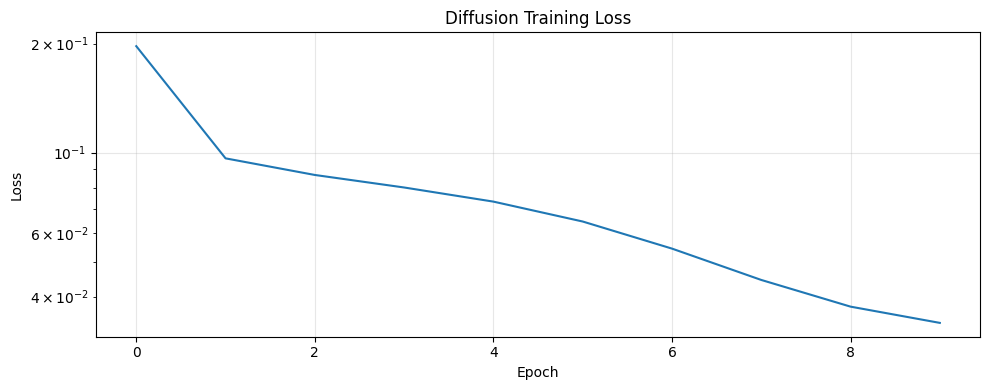

In [10]:
# ── Training loss curve ──
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Diffusion Training Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "diffusion_training_loss.png", dpi=150)
plt.show()

## Step 3b: Chunk Reconstruction Sanity Check

Before stitching, verify the diffusion model can reconstruct chunks from the training data.


                                                                                                    
1 / 256 [                                                            ]   0% | 12.2 Hz
t : 255
                                                                                                    
                                                                                                    
2 / 256 [                                                            ]   0% | 22.4 Hz
t : 254
                                                                                                    
                                                                                                    
3 / 256 [                                                            ]   1% | 31.3 Hz
t : 253
                                                                                                    
                                                                                                    
4 / 256 [ 

                                                                                                    
                                                                                                    
20 / 256 [####                                                        ]   7% | 97.1 Hz
t : 236
                                                                                                    
                                                                                                    
21 / 256 [####                                                        ]   8% | 98.8 Hz
t : 235
                                                                                                    
                                                                                                    
22 / 256 [#####                                                       ]   8% | 100.5 Hz
t : 234
                                                                                                    
       

                                                                                                    
                                                                                                    
53 / 256 [############                                                ]  20% | 128.9 Hz
t : 203
                                                                                                    
                                                                                                    
54 / 256 [############                                                ]  21% | 129.3 Hz
t : 202
                                                                                                    
                                                                                                    
55 / 256 [############                                                ]  21% | 129.8 Hz
t : 201
                                                                                                    
     

                                                                                                    
                                                                                                    
85 / 256 [###################                                         ]  33% | 138.6 Hz
t : 171
                                                                                                    
                                                                                                    
86 / 256 [####################                                        ]  33% | 138.8 Hz
t : 170
                                                                                                    
                                                                                                    
87 / 256 [####################                                        ]  33% | 139.0 Hz
t : 169
                                                                                                    
     

                                                                                                    
                                                                                                    
118 / 256 [###########################                                 ]  46% | 159.0 Hz
t : 138
                                                                                                    
                                                                                                    
119 / 256 [###########################                                 ]  46% | 158.5 Hz
t : 137
                                                                                                    
                                                                                                    
120 / 256 [############################                                ]  46% | 159.0 Hz
t : 136
                                                                                                    
  

                                                                                                    
                                                                                                    
150 / 256 [###################################                         ]  58% | 155.8 Hz
t : 106
                                                                                                    
                                                                                                    
151 / 256 [###################################                         ]  58% | 155.6 Hz
t : 105
                                                                                                    
                                                                                                    
152 / 256 [###################################                         ]  59% | 155.6 Hz
t : 104
                                                                                                    
  

                                                                                                    
                                                                                                    
182 / 256 [##########################################                  ]  71% | 156.2 Hz
t : 74
                                                                                                    
                                                                                                    
183 / 256 [##########################################                  ]  71% | 156.2 Hz
t : 73
                                                                                                    
                                                                                                    
184 / 256 [###########################################                 ]  71% | 156.3 Hz
t : 72
                                                                                                    
     

                                                                                                    
                                                                                                    
214 / 256 [##################################################          ]  83% | 156.6 Hz
t : 42
                                                                                                    
                                                                                                    
215 / 256 [##################################################          ]  83% | 141.4 Hz
t : 41
                                                                                                    
                                                                                                    
216 / 256 [##################################################          ]  84% | 140.3 Hz
t : 40
                                                                                                    
     

                                                                                                    
                                                                                                    
245 / 256 [#########################################################   ]  95% | 147.9 Hz
t : 11
                                                                                                    
                                                                                                    
246 / 256 [#########################################################   ]  96% | 146.3 Hz
t : 10
                                                                                                    
                                                                                                    
247 / 256 [#########################################################   ]  96% | 146.4 Hz
t : 9
                                                                                                    
      

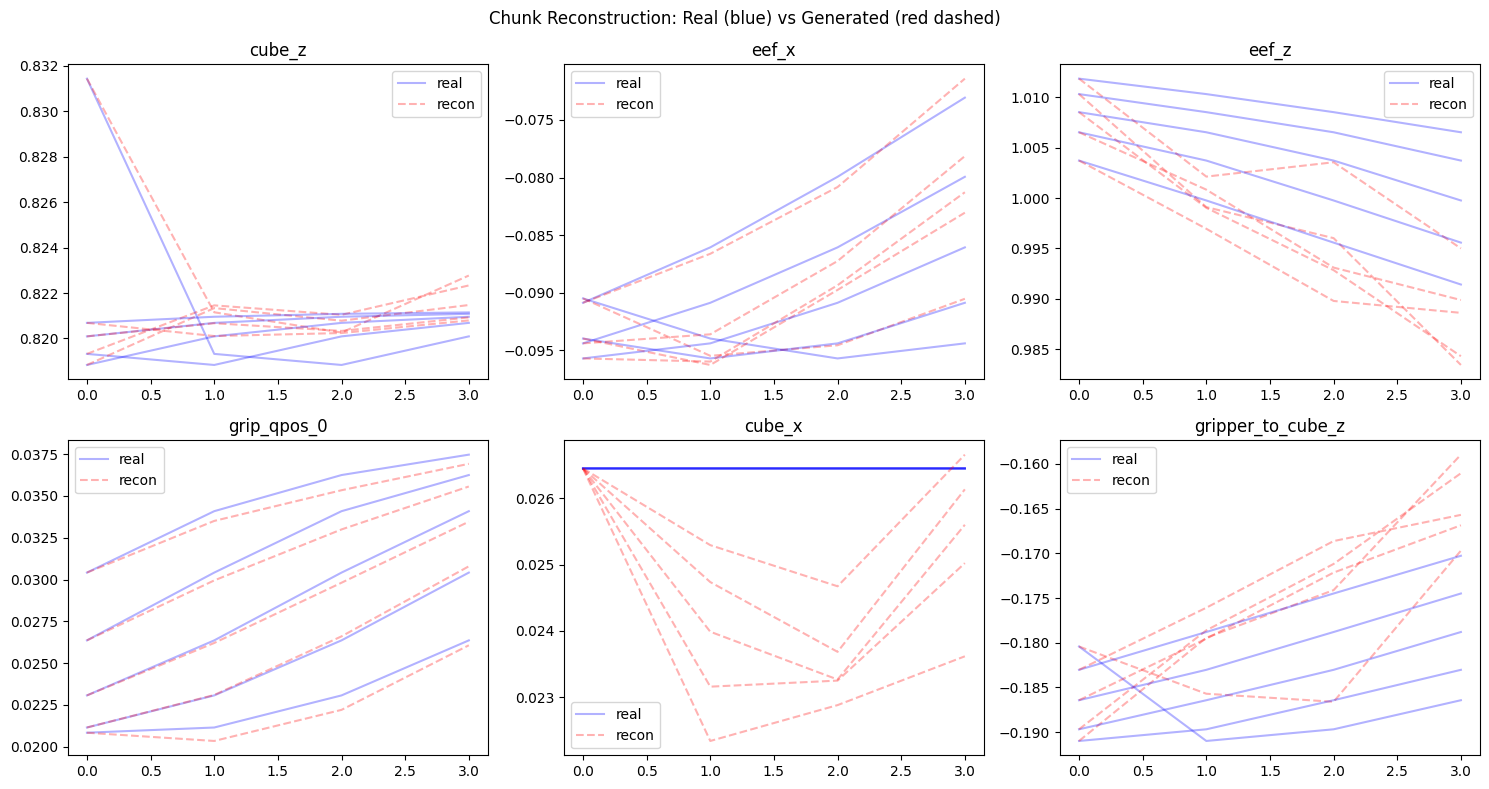

In [11]:
# Use EMA model for sampling
ema.ema_model.eval()

# Take a batch of real chunks
test_batch = torch.tensor(chunks_normalized[:NUM_SYNTHETIC_TRAJS], device=device)
conds = {0: test_batch[:, 0, :STATE_DIM]}

# Generate chunks via full denoising (conditioned on first state)
with torch.no_grad():
    generated = ema.ema_model.conditional_sample(
        shape=(NUM_SYNTHETIC_TRAJS, CHUNK_SIZE, TRANSITION_DIM),
        cond=conds,
    )[0]  # Sample namedtuple → trajectories

# Unnormalize both
real_unnorm = unnormalize_fn(test_batch).cpu().numpy()
gen_unnorm = unnormalize_fn(generated).cpu().numpy()

# Compute L2 error
l2_states = np.mean((real_unnorm[:, :, :STATE_DIM] - gen_unnorm[:, :, :STATE_DIM]) ** 2)
l2_actions = np.mean((real_unnorm[:, :, STATE_DIM:] - gen_unnorm[:, :, STATE_DIM:]) ** 2)
l2_total = np.mean((real_unnorm - gen_unnorm) ** 2)

print(f"Chunk reconstruction MSE:")
print(f"  States:  {l2_states:.6f}")
print(f"  Actions: {l2_actions:.6f}")
print(f"  Total:   {l2_total:.6f}")

# Visual comparison: 5 chunks, key dims
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
dim_names = ["cube_z", "eef_x", "eef_z", "grip_qpos_0", "cube_x", "gripper_to_cube_z"]
dim_indices = [2, 6, 8, 9, 0, 5]

for i, (name, idx) in enumerate(zip(dim_names, dim_indices)):
    ax = axes[i // 3, i % 3]
    for c in range(min(5, NUM_SYNTHETIC_TRAJS)):
        ax.plot(real_unnorm[c, :, idx], "b-", alpha=0.3, label="real" if c == 0 else "")
        ax.plot(gen_unnorm[c, :, idx], "r--", alpha=0.3, label="recon" if c == 0 else "")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Chunk Reconstruction: Real (blue) vs Generated (red dashed)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "chunk_reconstruction.png", dpi=150)
plt.show()

## Step 4: Unguided Stitching + OPE Estimation

Generate full trajectories via autoregressive chunk stitching (SOPE-style, 1-step overlap).
**No guidance** for this smoke test — the diffusion model generates trajectories reflecting
the behavior policy (human demos). We score with ground-truth reward (cube_z > 0.84).

In [12]:
def get_initial_states_from_data(offline_data, num_samples, device):
    """Sample initial states from the demo dataset."""
    all_initial = []
    for ep in offline_data:
        all_initial.append(ep["states"][0])  # First state of each episode
    all_initial = np.array(all_initial)
    
    # Sample with replacement if needed
    indices = np.random.choice(len(all_initial), num_samples, replace=True)
    initial_states = torch.tensor(all_initial[indices], dtype=torch.float32, device=device)
    return initial_states


def generate_unguided_trajectories(diffusion_model, initial_states,
                                    normalize_fn, unnormalize_fn,
                                    state_dim, action_dim,
                                    chunk_size, t_gen, device):
    """Generate full trajectories via autoregressive unguided stitching.
    
    Mirrors SOPE's generate_full_trajectory() in diffuser.py.
    Uses 1-step overlap: last state of chunk k = first state of chunk k+1.
    No guidance — just the diffusion model's learned distribution.
    """
    batch_size = initial_states.shape[0]
    transition_dim = state_dim + action_dim
    
    # Normalize initial states for conditioning
    padded = torch.cat([
        initial_states,
        torch.zeros(batch_size, action_dim, device=device)
    ], dim=1)
    normalized_initial = normalize_fn(padded)[:, :state_dim]
    
    all_trajectories = torch.zeros(batch_size, t_gen, transition_dim, device=device)
    conditions = {0: normalized_initial}
    total_generated = 0
    
    n_iterations = 0
    while total_generated < t_gen:
        n_iterations += 1
        steps_remaining = t_gen - total_generated
        
        # Generate a chunk using SOPE's conditional_sample (no guidance)
        shape = (batch_size, chunk_size, transition_dim)
        
        # Manual sampling loop (same as SOPE's p_sample_loop)
        x = torch.randn(shape, device=device)
        x = apply_conditioning(x, conditions, state_dim)
        
        for t_diff in reversed(range(diffusion_model.n_timesteps)):
            t_tensor = torch.full((batch_size,), t_diff, device=device, dtype=torch.long)
            
            # Standard p_sample: get model mean + variance, add noise
            model_mean, _, model_log_variance = diffusion_model.p_mean_variance(x=x, t=t_tensor)
            model_std = torch.exp(0.5 * model_log_variance)
            
            noise = torch.randn_like(x)
            nonzero_mask = (1 - (t_diff == 0) * 1.0)
            
            x = model_mean + nonzero_mask * model_std * noise
            x = apply_conditioning(x, conditions, state_dim)
        
        # Unnormalize the generated chunk
        chunk_unnorm = unnormalize_fn(x)
        
        # Store chunk (with 1-step overlap: store T-1 steps)
        steps_to_store = min(chunk_size - 1, steps_remaining)
        all_trajectories[:, total_generated:total_generated + steps_to_store] = chunk_unnorm[:, :steps_to_store]
        
        total_generated += steps_to_store
        
        if total_generated >= t_gen:
            break
        
        # Condition next chunk on last state of current chunk
        # Stay in normalized space from the diffusion output (avoid round-trip error)
        last_states_norm = x[:, -1, :state_dim]
        conditions = {0: last_states_norm}
    
    print(f"  Generated {total_generated} steps in {n_iterations} iterations")
    return all_trajectories.detach().cpu().numpy()


def score_trajectories_gt(trajectories, cube_z_index, threshold, gamma=1.0):
    """Score trajectories using ground-truth Lift reward.
    
    Args:
        trajectories: (B, T, transition_dim) — unnormalized
        cube_z_index: index of cube z-position in state
        threshold: lift success threshold (0.84)
        gamma: discount factor
        
    Returns:
        returns: (B,) per-trajectory discounted returns
        successes: (B,) per-trajectory success (any step above threshold)
    """
    B, T, D = trajectories.shape
    returns = np.zeros(B)
    successes = np.zeros(B, dtype=bool)
    
    for i in range(B):
        gamma_t = 1.0
        for t in range(T):
            cube_z = trajectories[i, t, cube_z_index]
            reward = 1.0 if cube_z > threshold else 0.0
            returns[i] += reward * gamma_t
            gamma_t *= gamma
            if reward > 0:
                successes[i] = True
    
    return returns, successes


print("Stitching and scoring functions defined.")

Stitching and scoring functions defined.


### Run Unguided Stitching

In [13]:
# ── Unguided stitching was defined above, this cell is no longer needed ──
print("Stitching functions already defined above. Running generation next...")

Stitching functions already defined above. Running generation next...


In [14]:
# ── Run unguided stitching ──
ema.ema_model.eval()

print("="*60)
print("Unguided Stitching (no policy guidance)")
print("="*60)

# Sample initial states from demo data
initial_states = get_initial_states_from_data(offline_data, NUM_SYNTHETIC_TRAJS, device)

# Generate trajectories without guidance
with torch.no_grad():
    synthetic_trajs = generate_unguided_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states,
        normalize_fn=normalize_fn,
        unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM,
        action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE,
        t_gen=T_GEN,
        device=device,
    )

# Score with ground-truth reward
ope_returns, ope_successes = score_trajectories_gt(
    synthetic_trajs, CUBE_Z_INDEX, LIFT_THRESHOLD, GAMMA
)
ope_estimate = float(np.mean(ope_returns))
ope_success_rate = float(np.mean(ope_successes))

print(f"\nOPE estimate (unguided): {ope_estimate:.4f} ± {np.std(ope_returns):.4f}")
print(f"Synthetic success rate:  {ope_success_rate*100:.1f}%")
print(f"Cube z range: [{synthetic_trajs[:,:,CUBE_Z_INDEX].min():.4f}, {synthetic_trajs[:,:,CUBE_Z_INDEX].max():.4f}]")

print(f"\nOracle V^π:  {oracle_value:.4f}")
print(f"OPE estimate: {ope_estimate:.4f}")
if oracle_value != 0:
    rel_error = abs(ope_estimate - oracle_value) / abs(oracle_value)
    print(f"Relative error: {rel_error:.2%}")
else:
    rel_error = float('inf')
    print("Relative error: N/A (oracle=0)")

Unguided Stitching (no policy guidance)


  Generated 60 steps in 20 iterations

OPE estimate (unguided): 14.9600 ± 5.9731
Synthetic success rate:  96.0%
Cube z range: [0.8170, 0.8782]

Oracle V^π:  0.5400
OPE estimate: 14.9600
Relative error: 2670.37%


## Step 5: Evaluation + Visualization

Compare OPE estimate to oracle, visualize synthetic trajectory quality.

In [15]:
print("="*60)
print("OPE EVALUATION RESULTS")
print("="*60)

print(f"\n{'Metric':<30} {'Value':>12}")
print("-" * 44)
print(f"{'Oracle V^π':<30} {oracle_value:>12.4f}")
print(f"{'Oracle success rate':<30} {oracle_success_rate*100:>11.1f}%")
print(f"{'OPE estimate (unguided)':<30} {ope_estimate:>12.4f}")
print(f"{'OPE std':<30} {np.std(ope_returns):>12.4f}")
print(f"{'Synthetic success rate':<30} {ope_success_rate*100:>11.1f}%")
print(f"{'Relative error':<30} {rel_error:>12.2%}")
print(f"{'Diffusion final loss':<30} {loss_history[-1]:>12.6f}")
print(f"{'Chunk recon MSE (states)':<30} {l2_states:>12.6f}")
print(f"{'Chunk recon MSE (actions)':<30} {l2_actions:>12.6f}")
print(f"{'N chunks':<30} {len(chunks):>12d}")

print(f"\n{'='*60}")
print("NOTE: Without guidance, OPE estimates the behavior policy (human demos)")
print("value, NOT the target policy value. This is expected for a smoke test.")
print(f"{'='*60}")

OPE EVALUATION RESULTS

Metric                                Value
--------------------------------------------
Oracle V^π                           0.5400
Oracle success rate                   54.0%
OPE estimate (unguided)             14.9600
OPE std                              5.9731
Synthetic success rate                96.0%
Relative error                     2670.37%
Diffusion final loss               0.033863
Chunk recon MSE (states)           0.000004
Chunk recon MSE (actions)          0.017120
N chunks                               8866

NOTE: Without guidance, OPE estimates the behavior policy (human demos)
value, NOT the target policy value. This is expected for a smoke test.


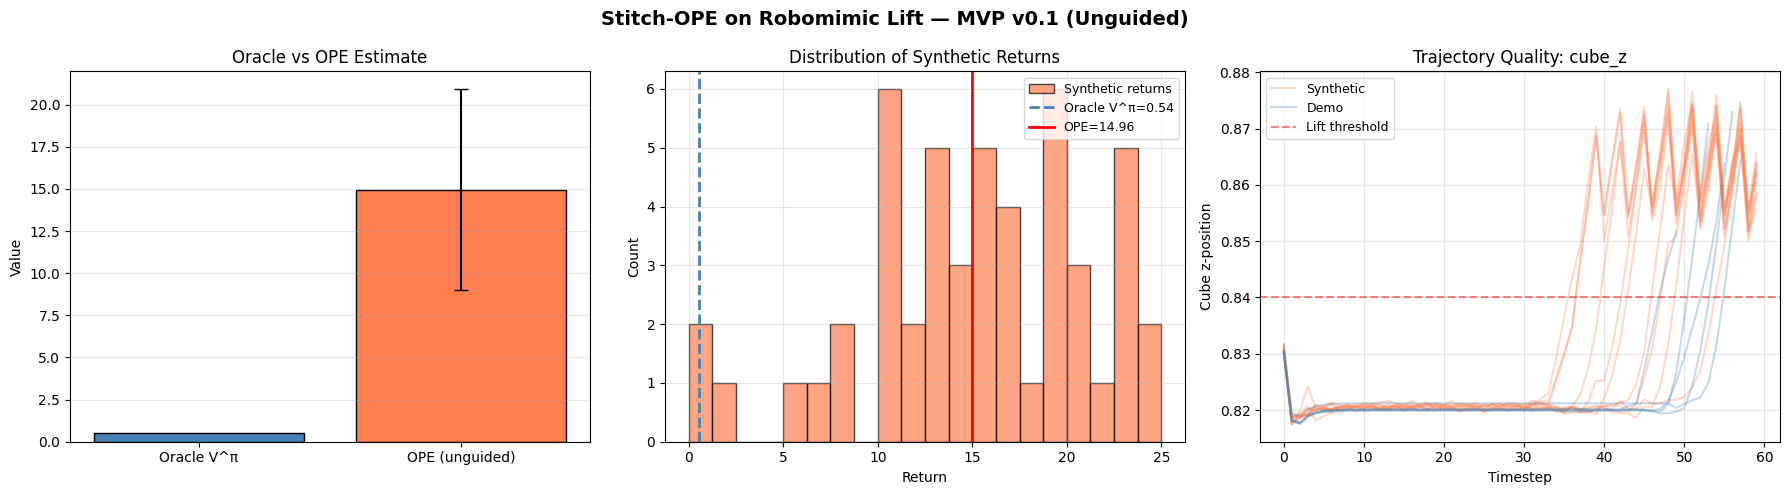

In [16]:
# ── Visualization: 3-panel summary figure ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Oracle vs OPE bar chart
bars = axes[0].bar(["Oracle V^π", "OPE (unguided)"], [oracle_value, ope_estimate],
                   color=["steelblue", "coral"], edgecolor="black")
axes[0].errorbar(1, ope_estimate, yerr=np.std(ope_returns), fmt="none", color="black", capsize=5)
axes[0].set_ylabel("Value")
axes[0].set_title("Oracle vs OPE Estimate")
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Histogram of synthetic returns + oracle line
axes[1].hist(ope_returns, bins=20, alpha=0.7, color="coral", edgecolor="black", label="Synthetic returns")
axes[1].axvline(x=oracle_value, color="steelblue", linestyle="--", linewidth=2, label=f"Oracle V^π={oracle_value:.2f}")
axes[1].axvline(x=ope_estimate, color="red", linestyle="-", linewidth=2, label=f"OPE={ope_estimate:.2f}")
axes[1].set_xlabel("Return")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Synthetic Returns")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Panel 3: Cube z trajectories (synthetic vs demo distribution)
for j in range(min(10, NUM_SYNTHETIC_TRAJS)):
    axes[2].plot(synthetic_trajs[j, :, CUBE_Z_INDEX], alpha=0.3, color="coral",
                 label="Synthetic" if j == 0 else "")
# Plot a few real demo trajectories for comparison
for j in range(min(5, len(offline_data))):
    axes[2].plot(offline_data[j]["states"][:T_GEN, CUBE_Z_INDEX], alpha=0.3, color="steelblue",
                 label="Demo" if j == 0 else "")
axes[2].axhline(y=LIFT_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Lift threshold")
axes[2].set_xlabel("Timestep")
axes[2].set_ylabel("Cube z-position")
axes[2].set_title("Trajectory Quality: cube_z")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stitch-OPE on Robomimic Lift — MVP v0.1 (Unguided)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ope_summary_mvp.png", dpi=150, bbox_inches="tight")
plt.show()

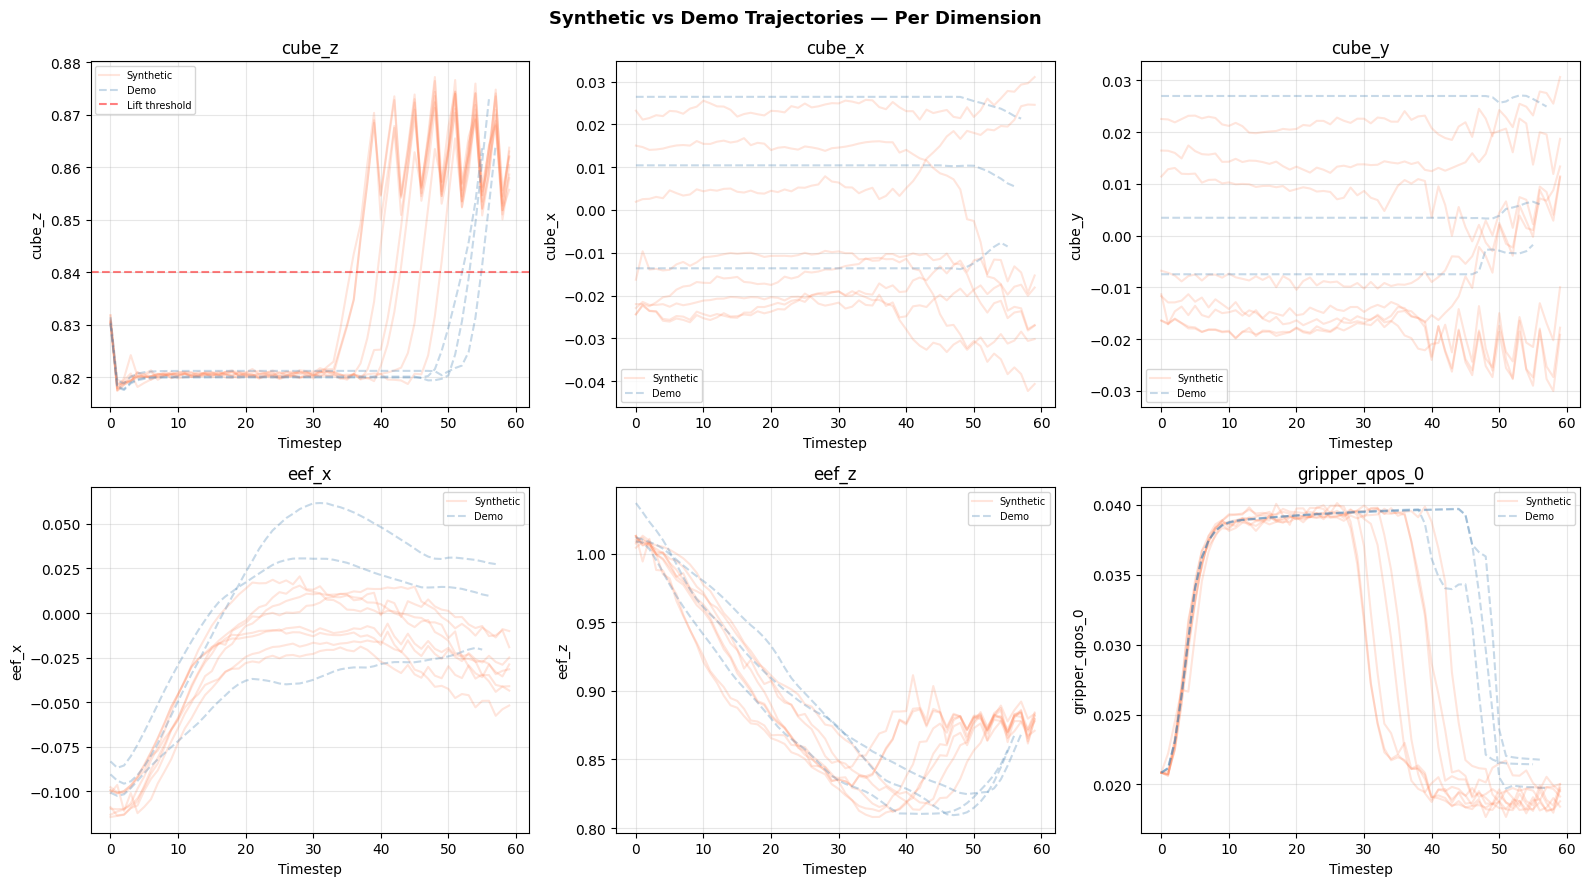

In [17]:
# ── Trajectory quality: per-dimension comparison ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

dim_names_traj = ["cube_z", "cube_x", "cube_y", "eef_x", "eef_z", "gripper_qpos_0"]
dim_indices_traj = [2, 0, 1, 6, 8, 9]

for i, (name, idx) in enumerate(zip(dim_names_traj, dim_indices_traj)):
    ax = axes[i // 3, i % 3]
    
    # Synthetic trajectories
    for j in range(min(8, NUM_SYNTHETIC_TRAJS)):
        ax.plot(synthetic_trajs[j, :, idx], alpha=0.2, color="coral",
                label="Synthetic" if j == 0 else "")
    
    # Demo trajectories for comparison
    for j in range(min(3, len(offline_data))):
        ax.plot(offline_data[j]["states"][:T_GEN, idx], alpha=0.3, color="steelblue",
                linestyle="--", label="Demo" if j == 0 else "")
    
    if name == "cube_z":
        ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Lift threshold")
    
    ax.set_xlabel("Timestep")
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("Synthetic vs Demo Trajectories — Per Dimension", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "synthetic_trajectories_mvp.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: Save Results

In [18]:
# ── Save all results to JSON ──
results = {
    "config": {
        "state_dim": STATE_DIM,
        "action_dim": ACTION_DIM,
        "transition_dim": TRANSITION_DIM,
        "chunk_size": CHUNK_SIZE,
        "n_diffusion_steps": N_DIFFUSION_STEPS,
        "dim_mults": list(DIM_MULTS),
        "base_dim": BASE_DIM,
        "action_weight": ACTION_WEIGHT,
        "predict_epsilon": PREDICT_EPSILON,
        "train_epochs": TRAIN_EPOCHS,
        "train_steps_per_epoch": TRAIN_STEPS_PER_EPOCH,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "oracle_source": str(ORACLE_JSON),
        "oracle_num_rollouts": len(oracle_returns),
        "num_synthetic_trajs": NUM_SYNTHETIC_TRAJS,
        "t_gen": T_GEN,
        "gamma": GAMMA,
        "guidance": "none (unguided smoke test)",
        "target_policy": "diffusion_policy (pre-trained)",
        "target_policy_ckpt": str(CKPT_DIR),
    },
    "oracle": {
        "value": oracle_value,
        "success_rate": oracle_success_rate,
        "std": float(np.std(oracle_returns)),
        "returns": oracle_returns.tolist(),
    },
    "ope": {
        "estimate": ope_estimate,
        "success_rate": ope_success_rate,
        "std": float(np.std(ope_returns)),
        "relative_error": rel_error,
        "returns": ope_returns.tolist(),
    },
    "training": {
        "final_loss": float(loss_history[-1]),
        "n_chunks": len(chunks),
        "n_model_params": n_params,
        "chunk_recon_mse_states": float(l2_states),
        "chunk_recon_mse_actions": float(l2_actions),
        "chunk_recon_mse_total": float(l2_total),
    },
}

results_path = RESULTS_DIR / "mvp_sope_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")
print(f"\nFigures saved to:")
print(f"  {RESULTS_DIR / 'diffusion_training_loss.png'}")
print(f"  {RESULTS_DIR / 'chunk_reconstruction.png'}")
print(f"  {RESULTS_DIR / 'ope_summary_mvp.png'}")
print(f"  {RESULTS_DIR / 'synthetic_trajectories_mvp.png'}")

print("\n" + "="*60)
print("MVP v0.1 COMPLETE (Pipeline Smoke Test)")
print("="*60)
print("\nNext: Add policy guidance (v0.2) to steer generation toward target policy.")

Results saved to /home1/reishuen/latent_sope/results/2026-03-10/mvp_sope_results.json

Figures saved to:
  /home1/reishuen/latent_sope/results/2026-03-10/diffusion_training_loss.png
  /home1/reishuen/latent_sope/results/2026-03-10/chunk_reconstruction.png
  /home1/reishuen/latent_sope/results/2026-03-10/ope_summary_mvp.png
  /home1/reishuen/latent_sope/results/2026-03-10/synthetic_trajectories_mvp.png

MVP v0.1 COMPLETE (Pipeline Smoke Test)

Next: Add policy guidance (v0.2) to steer generation toward target policy.
